In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

In [2]:
# Create dense clusters
X, _ = make_blobs(
    n_samples=400,
    centers=[(2,2), (8,8), (2,8)],
    cluster_std=[0.3, 0.4, 0.35],  # Dense clusters
    random_state=42)

In [3]:
# Add noise points manually
noise = np.random.uniform(low=0, high=10, size=(30,2))
X = np.vstack([X, noise])

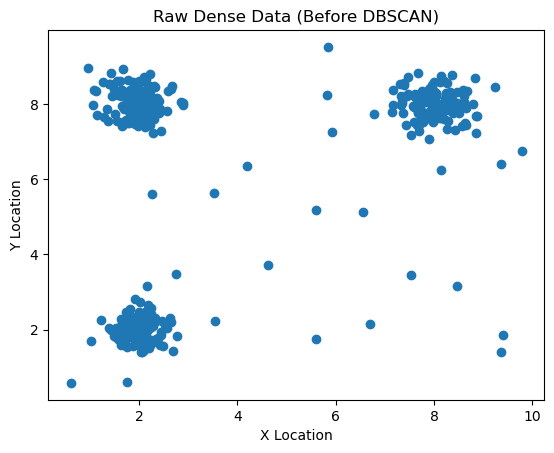

In [4]:
# Visualize raw data
plt.scatter(X[:,0], X[:,1])
plt.title("Raw Dense Data (Before DBSCAN)")
plt.xlabel("X Location")
plt.ylabel("Y Location")
plt.show()

In [11]:
from sklearn.neighbors import NearestNeighbors

neighbors =  NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)

In [6]:
distances = np.sort(distances[:,4])

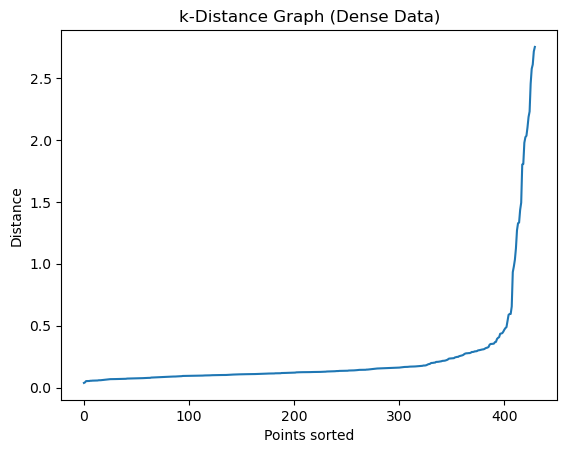

In [7]:
plt.plot(distances)
plt.title("k-Distance Graph (Dense Data)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

In [8]:
##apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples = 5)
labels = dbscan.fit_predict(X)

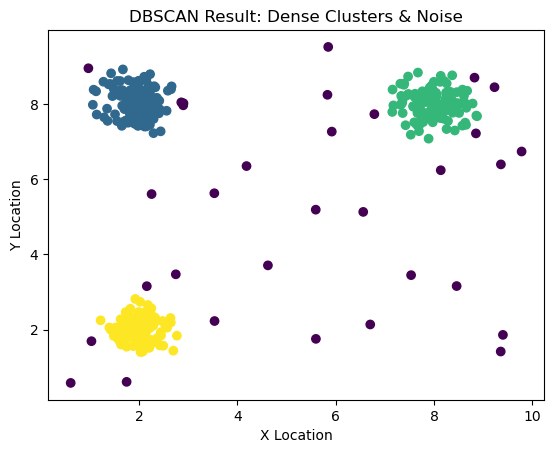

In [9]:
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN Result: Dense Clusters & Noise")
plt.xlabel("X Location")
plt.ylabel("Y Location")
plt.show()

In [10]:
sum(labels == -1)

32